In [22]:
import numpy as np
import pandas as pd
import gensim.downloader as api
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
model = api.load("glove-wiki-gigaword-300")

[==================================================] 100.0% 376.1/376.1MB downloaded


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, concatenate
from tensorflow.keras.models import Model

In [8]:
df = pd.read_csv("/content/Preprocessed_DonorsChoose_dataset.csv")
df.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0.0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0.0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0.0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0.0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0.0


In [9]:
df.shape


(9524, 14)

In [10]:
df['project_is_approved'].value_counts()

,count
project_is_approved,
1,8104
0,1420


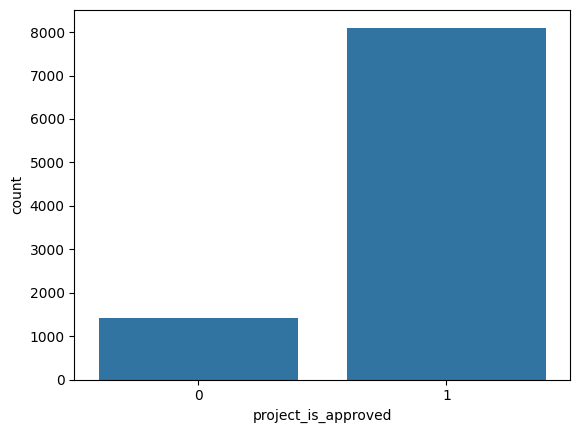

In [11]:
sns.countplot(x='project_is_approved', data=df)
plt.show()

In [12]:
df['text'] = df['cleaned_titles'] + " " + df['cleaned_essays']

In [13]:
def clean_text(text):
    if not isinstance(text, str):
        text = ''
    text = text.lower()
    text = re.sub(r'<.*?>','', text)
    text = re.sub(r'[^a-zA-Z ]','', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range=(1,3), max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [17]:
!pip install gensim
from gensim.models import KeyedVectors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.8 MB/s eta 0:00:00


In [25]:
from gensim.models import KeyedVectors
def document_vector(doc):
    words = doc.split()
    vectors = [model[w] for w in words if w in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

X_w2v = np.array(df['clean_text'].apply(document_vector).tolist())

In [27]:
y = df['project_is_approved']

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42)

For Word2Vec:

In [28]:
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42)

In [29]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       301
           1       0.84      1.00      0.91      1604

    accuracy                           0.84      1905
   macro avg       0.42      0.50      0.46      1905
weighted avg       0.71      0.84      0.77      1905



In [30]:
svm = SVC()
svm.fit(X_train_tfidf, y_train)

y_pred = svm.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       301
           1       0.84      1.00      0.91      1604

    accuracy                           0.84      1905
   macro avg       0.42      0.50      0.46      1905
weighted avg       0.71      0.84      0.77      1905



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

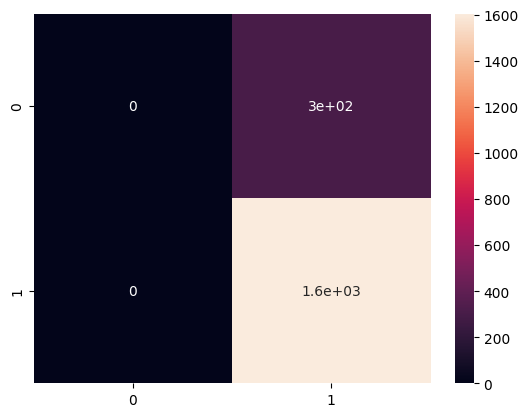

In [31]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

In [32]:
input_tfidf = Input(shape=(X_train_tfidf.shape[1],))
x1 = Dense(128, activation='relu')(input_tfidf)
x1 = Dropout(0.3)(x1)

input_w2v = Input(shape=(X_train_w2v.shape[1],))
x2 = Dense(128, activation='relu')(input_w2v)
x2 = Dropout(0.3)(x2)

In [33]:
merged = concatenate([x1, x2])
x = Dense(64, activation='relu')(merged)
output = Dense(1, activation='sigmoid')(x)

In [34]:
model = Model(inputs=[input_tfidf, input_w2v], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
model.fit(
    [X_train_tfidf.toarray(), X_train_w2v],
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8348 - loss: 0.4489 - val_accuracy: 0.8589 - val_loss: 0.3907
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8479 - loss: 0.3435 - val_accuracy: 0.8589 - val_loss: 0.4124
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9038 - loss: 0.2323 - val_accuracy: 0.8222 - val_loss: 0.5056
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9456 - loss: 0.1413 - val_accuracy: 0.8104 - val_loss: 0.6436
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9781 - loss: 0.0730 - val_accuracy: 0.8031 - val_loss: 0.8497


In [36]:
pred = model.predict([X_test_tfidf.toarray(), X_test_w2v])

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [39]:
lr_acc = accuracy_score(y_test, y_pred)
lr_prec = precision_score(y_test, y_pred)
lr_rec = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

In [42]:
svm_acc = accuracy_score(y_test, y_pred)
svm_prec = precision_score(y_test, y_pred)
svm_rec = recall_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)

In [41]:
y_pred_dl = (model.predict([X_test_tfidf.toarray(), X_test_w2v]) > 0.5).astype("int32")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [43]:
dl_acc = accuracy_score(y_test, y_pred_dl)
dl_prec = precision_score(y_test, y_pred_dl)
dl_rec = recall_score(y_test, y_pred_dl)
dl_f1 = f1_score(y_test, y_pred_dl)

In [44]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Deep Learning"],
    "Accuracy": [lr_acc, svm_acc, dl_acc],
    "Precision": [lr_prec, svm_prec, dl_prec],
    "Recall": [lr_rec, svm_rec, dl_rec],
    "F1 Score": [lr_f1, svm_f1, dl_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.841995,0.841995,1.000000,0.914221
1,SVM,0.841995,0.841995,1.000000,0.914221
2,Deep Learning,0.795276,0.857059,0.908354,0.881961


Confusion Matrix

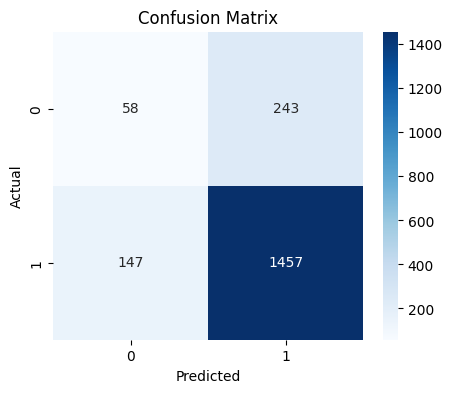

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dl)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


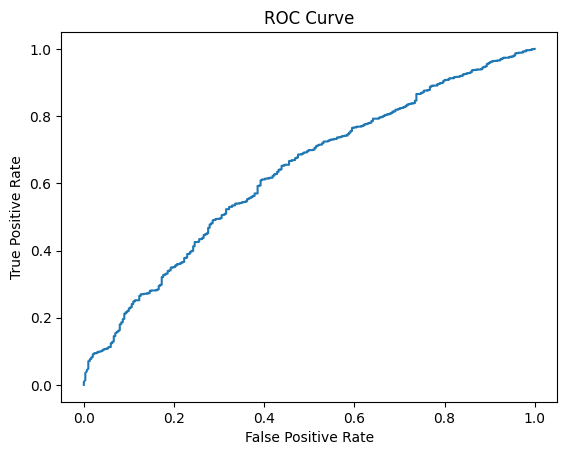

In [46]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict([X_test_tfidf.toarray(), X_test_w2v])

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

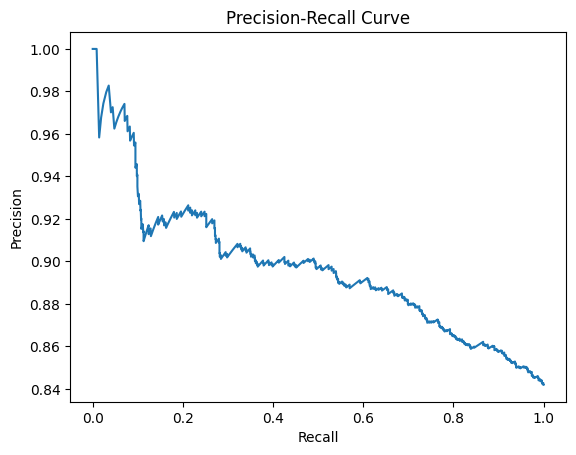

In [47]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()